# GenCorr-Sep + ESSD: Monolithic Kaggle Training
This notebook contains the entire model architecture in single cells so you can easily modify it on Kaggle.

In [17]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchaudio
import soundfile as sf
import numpy as np
import math
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from tqdm.auto import tqdm
from scipy.optimize import linear_sum_assignment

# ---------------------------------------------------------
# DATASET CONFIGURATION
# ---------------------------------------------------------
TRAIN_DATA_PATH = "/kaggle/input/datasets/mruddunijmodha/librimix-s5/Libri5Mix/wav16k/min/train-100"
TEST_DATA_PATH = "/kaggle/input/datasets/mruddunijmodha/librimix-s5/Libri5Mix/wav16k/min/test"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [18]:
"""
Dataset loader for 5-speaker speech separation.
Loads mixture and corresponding clean source audio files.
"""
import torch
from torch.utils.data import Dataset, DataLoader
import soundfile as sf
import os
import numpy as np


class SpeechSeparationDataset(Dataset):
    """
    Loads data from a directory structured as:
    data_dir/
      5mix/
        mix_0000000.wav
      s1/
        mix_0000000.wav
      s2/
        mix_0000000.wav
      ...
      s5/
        mix_0000000.wav
    """

    def __init__(self, data_dir: str, N: int = 5, max_length: int = 64000):
        super().__init__()
        self.data_dir = data_dir
        self.N = N
        self.max_length = max_length
        
        # In a real scenario, we'd list all files. Here we just take what's in the folder.
        self.mix_dir = os.path.join(data_dir, "mix_clean")
        self.filenames = sorted(os.listdir(self.mix_dir)) if os.path.exists(self.mix_dir) else []

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        filename = self.filenames[idx]
        
        # Load mixture
        mix_path = os.path.join(self.mix_dir, filename)
        mix_audio, sr = sf.read(mix_path)
        
        # Load N sources
        sources = []
        for i in range(1, self.N + 1):
            src_path = os.path.join(self.data_dir, f"s{i}", filename)
            src_audio, _ = sf.read(src_path)
            sources.append(src_audio)
            
        # Convert to float32 tensors (Soundfile loads float64 by default)
        mix_tensor = torch.tensor(mix_audio, dtype=torch.float32)
        sources_tensor = torch.tensor(np.array(sources), dtype=torch.float32)
        
        # ── Fix: Crop or Pad to fixed length for batching ──
        T_current = mix_tensor.shape[-1]
        if T_current > self.max_length:
            # Random crop
            start = torch.randint(0, T_current - self.max_length + 1, (1,)).item()
            mix_tensor = mix_tensor[start : start + self.max_length]
            sources_tensor = sources_tensor[:, start : start + self.max_length]
        elif T_current < self.max_length:
            # Zero pad
            pad_amount = self.max_length - T_current
            mix_tensor = torch.nn.functional.pad(mix_tensor, (0, pad_amount))
            sources_tensor = torch.nn.functional.pad(sources_tensor, (0, pad_amount))
            
        # Add channel dimension: [1, T] and [N, T]
        mix_tensor = mix_tensor.unsqueeze(0)
        
        return mix_tensor, sources_tensor


def get_dataloader(data_dir: str, batch_size: int = 1, N: int = 5):
    dataset = SpeechSeparationDataset(data_dir, N=N)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [19]:
"""
GenCorr-Sep + ESSD: 5-Speaker Speech Separation Pipeline
=========================================================

Component 1: AudioEncoder & AudioDecoder
- AudioEncoder: 1D Conv that maps waveform → latent representation
- AudioDecoder: 1D TransposedConv that maps latent → waveform

Reference: technical_architecture.md, Section 3 & 7
"""

import torch
import torch.nn as nn


class AudioEncoder(nn.Module):
    """
    1D Convolutional encoder (TasNet-style).
    
    Converts raw waveform into a high-dimensional latent representation.
    Uses a single Conv1d layer followed by ReLU activation.
    
    Args:
        C (int): Number of output channels (latent dimension). Default: 256
        kernel_size (int): Encoder filter length. Default: 16 (~1ms at 16kHz)
        stride (int): Encoder hop size. Default: 8 (50% overlap)
    
    Shapes:
        Input:  [B, 1, T]      e.g., [1, 1, 64000]
        Output: [B, C, L]      e.g., [1, 256, 8000]
        where L = ceil((T - kernel_size) / stride) + 1
    """

    def __init__(self, C: int = 256, kernel_size: int = 16, stride: int = 8):
        super().__init__()
        self.conv = nn.Conv1d(
            in_channels=1,
            out_channels=C,
            kernel_size=kernel_size,
            stride=stride,
            padding=0,       # No padding — we handle length alignment in the decoder
            bias=False,
        )
        self.activation = nn.ReLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: [B, 1, T] — Raw waveform mixture
        Returns:
            [B, C, L] — Encoded latent features
        """
        return self.activation(self.conv(x))


class AudioDecoder(nn.Module):
    """
    1D Transposed Convolutional decoder (TasNet-style).
    
    Mirrors the AudioEncoder: converts latent representation back into
    a raw waveform. Uses a single ConvTranspose1d layer.
    
    GOTCHA #6: ConvTranspose1d may produce output length T' != T_original.
    We store T_original during encoding and truncate/pad during decoding.
    
    Args:
        C (int): Number of input channels (must match encoder C). Default: 256
        kernel_size (int): Decoder filter length. Default: 16
        stride (int): Decoder hop size. Default: 8
    
    Shapes:
        Input:  [B, C, L]    e.g., [1, 256, 8000]
        Output: [B, 1, T']   e.g., [1, 1, 64000] (T' is truncated to match T_original)
    """

    def __init__(self, C: int = 256, kernel_size: int = 16, stride: int = 8):
        super().__init__()
        self.decoder = nn.ConvTranspose1d(
            in_channels=C,
            out_channels=1,
            kernel_size=kernel_size,
            stride=stride,
            padding=0,
            bias=False,
        )

    def forward(self, x: torch.Tensor, T_original: int) -> torch.Tensor:
        """
        Args:
            x: [B, C, L] — Encoded latent features
            T_original: int — Original waveform length (for truncation)
        Returns:
            [B, 1, T_original] — Reconstructed waveform
        """
        out = self.decoder(x)  # [B, 1, T']

        # GOTCHA #6: Truncate or pad to match original waveform length
        T_out = out.shape[-1]
        if T_out > T_original:
            out = out[..., :T_original]
        elif T_out < T_original:
            out = nn.functional.pad(out, (0, T_original - T_out))

        return out


# ─────────────────────────────────────────────────────────────────────
# Test: Verify shapes and roundtrip (Step 1 from Build Checklist)
# ─────────────────────────────────────────────────────────────────────

In [20]:
"""
Component 2: Separation Encoder (Feature Extractor)

Processes the encoded mixture features BEFORE the split.
Extracts intermediate skip connections at each block.

Reference: technical_architecture.md, Section 4
"""
import torch
import torch.nn as nn


class SeparationBlock(nn.Module):
    """
    A single block of the Separation Encoder.
    Using standard TransformerEncoderLayer for simplicity and compatibility
    without requiring custom CUDA kernels (like Mamba).
    """

    def __init__(self, C: int = 256, nhead: int = 8, dim_feedforward: int = 1024):
        super().__init__()
        # Using batch_first=True so input is [B, L, C] instead of [L, B, C]
        self.transformer = nn.TransformerEncoderLayer(
            d_model=C,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            batch_first=True,
            norm_first=True,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: [B, C, L]
        Returns:
            [B, C, L]
        """
        # Transformer expects [B, L, C] with batch_first=True
        x_trans = x.transpose(1, 2)
        out = self.transformer(x_trans)
        return out.transpose(1, 2)


class SeparationEncoder(nn.Module):
    """
    Stacks D blocks and collects skip connections.
    """

    def __init__(
        self, C: int = 256, D: int = 4, nhead: int = 8, dim_feedforward: int = 1024
    ):
        super().__init__()
        self.blocks = nn.ModuleList(
            [SeparationBlock(C, nhead, dim_feedforward) for _ in range(D)]
        )

    def forward(self, x: torch.Tensor):
        """
        Args:
            x: [B, C, L]
        Returns:
            out: [B, C, L]
            skips: list of [B, C, L] tensors (length D)
        """
        skips = []
        for block in self.blocks:
            x = block(x)
            skips.append(x)
        return x, skips


# ─────────────────────────────────────────────────────────────────────
# Test: Verify shapes and skip connections (Step 2 from Build Checklist)
# ─────────────────────────────────────────────────────────────────────

In [21]:
"""
Component 3: Early Split Layer

Splits the monolithic latent representation into N distinct speaker streams.
Crucially, it also handles the expansion of the skip connections.

Reference: technical_architecture.md, Section 5
"""
import torch
import torch.nn as nn


class EarlySplitLayer(nn.Module):
    """
    Expands channel dimension to N*C via 1x1 Conv, then reshapes.
    Skip connections are broadcasted via .expand() to save memory.
    """

    def __init__(self, C: int = 256, N: int = 5):
        super().__init__()
        self.C = C
        self.N = N
        # 1x1 Conv to expand features: [B, C, L] -> [B, N*C, L]
        self.expand_conv = nn.Conv1d(
            in_channels=C, out_channels=N * C, kernel_size=1, bias=False
        )

    def forward(self, x: torch.Tensor, skips: list[torch.Tensor]):
        """
        Args:
            x: [B, C, L]
            skips: List of [B, C, L]
        Returns:
            split_x: [B, N, C, L]
            split_skips: List of [B, N, C, L]
        """
        B, C, L = x.shape
        
        # Main feature split
        x = self.expand_conv(x)  # [B, N*C, L]
        split_x = x.view(B, self.N, self.C, L)  # [B, N, C, L]
        
        # Skip connection split (Memory efficient broadcast)
        split_skips = []
        for skip in skips:
            # skip is [B, C, L] -> [B, 1, C, L] -> [B, N, C, L]
            split_skips.append(skip.unsqueeze(1).expand(-1, self.N, -1, -1))
            
        return split_x, split_skips


# ─────────────────────────────────────────────────────────────────────
# Test: Verify shapes and skip connections (Step 3 from Build Checklist)
# ─────────────────────────────────────────────────────────────────────

In [22]:
"""
Component 4: Siamese Reconstruction Decoder

The heart of the ESSD architecture. Processes each speaker's latent stream
independently using SHARED weights via the B*N reshape trick.

Reference: technical_architecture.md, Section 6
"""
import torch
import torch.nn as nn


class DecoderBlock(nn.Module):
    """
    A single block of the Siamese Decoder.
    Takes input features and adds the skip connection from the Encoder.
    """

    def __init__(self, C: int = 256, nhead: int = 8, dim_feedforward: int = 1024):
        super().__init__()
        # Skip connection combination (using addition, so we just norm)
        self.norm = nn.LayerNorm(C)
        
        # Core processing block (same as encoder for symmetry)
        # In a real model, this might be a custom Decoder block
        self.block = SeparationBlock(C, nhead, dim_feedforward)

    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: [B*N, C, L]
            skip: [B*N, C, L]
        Returns:
            [B*N, C, L]
        """
        # Add skip connection
        x = x + skip
        
        # LayerNorm expects features at the last dimension, so we transpose
        # x is [B*N, C, L] -> transpose -> [B*N, L, C] -> norm -> transpose back
        x = self.norm(x.transpose(1, 2)).transpose(1, 2)
        
        # Apply transformer block
        out = self.block(x)
        return out


class SiameseDecoder(nn.Module):
    """
    Stacks D blocks and shares them across all N speakers.
    """

    def __init__(self, C: int = 256, D: int = 4, N: int = 5, nhead: int = 8, dim_feedforward: int = 1024):
        super().__init__()
        self.N = N
        self.D = D
        # Shared blocks!
        self.blocks = nn.ModuleList(
            [DecoderBlock(C, nhead, dim_feedforward) for _ in range(D)]
        )

    def forward(self, x: torch.Tensor, split_skips: list[torch.Tensor]) -> torch.Tensor:
        """
        Args:
            x: [B, N, C, L]
            split_skips: List of [B, N, C, L]
        Returns:
            [B, N, C, L]
        """
        B, N, C, L = x.shape
        assert N == self.N, f"Expected N={self.N}, got {N}"
        assert len(split_skips) == self.D, f"Expected {self.D} skips, got {len(split_skips)}"
        
        # ─────────────────────────────────────────────────────────
        # THE SIAMESE RESHAPE (Gotcha #1 from local test checklist)
        # ─────────────────────────────────────────────────────────
        x = x.reshape(B * N, C, L)
        
        for i, block in enumerate(self.blocks):
            # Also reshape skip connections
            skip = split_skips[i]           # [B, N, C, L]
            skip = skip.reshape(B * N, C, L)   # [B*N, C, L]
            
            x = block(x, skip)
            
        # ─────────────────────────────────────────────────────────
        # RESHAPE BACK
        # ─────────────────────────────────────────────────────────
        x = x.reshape(B, N, C, L)
        
        return x


# ─────────────────────────────────────────────────────────────────────
# Test: Verify B*N reshape and weight sharing (Step 4 from Build Checklist)
# ─────────────────────────────────────────────────────────────────────

In [23]:
"""
Component 9: Stage 1 Full Assembly (ESSD)

Wires together all the components for the Discriminative Separator.
This model takes the raw mixture and outputs the 5 coarse separated waveforms.

Reference: technical_architecture.md, Section 9
"""
import torch
import torch.nn as nn


class Stage1_ESSD(nn.Module):
    """
    Early Split Shared Decoder architecture for 5-speaker separation.
    """

    def __init__(self, C: int = 256, N: int = 5, D_enc: int = 4, D_dec: int = 4):
        super().__init__()
        self.audio_encoder = AudioEncoder(C=C)
        self.sep_encoder = SeparationEncoder(C=C, D=D_enc)
        self.split_layer = EarlySplitLayer(C=C, N=N)
        self.siamese_decoder = SiameseDecoder(C=C, D=D_dec, N=N)
        self.audio_decoder = AudioDecoder(C=C)

    def forward(self, mixture: torch.Tensor) -> torch.Tensor:
        """
        Args:
            mixture: [B, 1, T]
        Returns:
            estimated: [B, N, T] — 5 rough separated waveforms
        """
        # Store original length for truncation in decoder
        T_original = mixture.shape[-1]
        
        # 1. Encode waveform to latent
        encoded = self.audio_encoder(mixture)             # [B, C, L]
        
        # 2. Process with separation encoder (extract speaker patterns)
        sep_features, skips = self.sep_encoder(encoded)   # [B, C, L], list of [B, C, L]
        
        # 3. Split into N speaker streams
        split_features, split_skips = self.split_layer(sep_features, skips)
                                                          # [B, N, C, L], list of [B, N, C, L]
        
        # 4. Process each speaker with shared decoder
        decoded = self.siamese_decoder(split_features, split_skips)
                                                          # [B, N, C, L]
        
        # 5. Convert back to waveform
        B_N = decoded.shape[0] * decoded.shape[1]
        decoded_flat = decoded.reshape(B_N, decoded.shape[2], decoded.shape[3]) # [B*N, C, L]
        
        estimated_flat = self.audio_decoder(decoded_flat, T_original) # [B*N, 1, T]
        estimated = estimated_flat.reshape(mixture.shape[0], self.split_layer.N, T_original) # [B, N, T]
        
        return estimated


# ─────────────────────────────────────────────────────────────────────
# Test: Verify end-to-end forward/backward (Step 5 from Build Checklist)
# ─────────────────────────────────────────────────────────────────────

In [24]:
"""
Component 6: PIT Loss Module

Computes the Permutation Invariant Training (PIT) loss for Stage 1.
Because Stage 1 output has arbitrary permutation, we must use the Hungarian
algorithm to find the optimal assignment against ground truth.

Reference: technical_architecture.md, Section 8
"""
import torch
import torch.nn as nn
from scipy.optimize import linear_sum_assignment


def si_snr_loss(estimated: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    """
    Scale-Invariant Signal-to-Noise Ratio (SI-SNR).
    Returns NEGATIVE SI-SNR (so it can be minimized).
    
    Args:
        estimated: [..., T] — Estimated audio
        target:    [..., T] — Ground truth clean audio
    Returns:
        Loss (scalar)
    """
    # Zero-mean normalization
    estimated = estimated - estimated.mean(dim=-1, keepdim=True)
    target = target - target.mean(dim=-1, keepdim=True)
    
    # Dot product
    dot = torch.sum(estimated * target, dim=-1, keepdim=True)
    s_target_energy = torch.sum(target ** 2, dim=-1, keepdim=True) + 1e-8
    
    # Projection
    proj = dot * target / s_target_energy
    
    # Noise
    noise = estimated - proj
    
    # SI-SNR
    si_snr = 10 * torch.log10(
        torch.sum(proj ** 2, dim=-1) / (torch.sum(noise ** 2, dim=-1) + 1e-8) + 1e-8
    )
    
    # We want to maximize SI-SNR, so we return negative
    return -si_snr.mean()


def pit_loss(estimated: torch.Tensor, targets: torch.Tensor, loss_fn=si_snr_loss) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Computes PIT loss using the Hungarian algorithm.
    
    Args:
        estimated: [B, N, T] — Model predictions
        targets:   [B, N, T] — Ground truth sources
        loss_fn:   Callable — Loss function between two [T] arrays
        
    Returns:
        total_loss: (scalar) torch.Tensor containing the combined loss
        best_perm:  [B, N] long tensor of optimal assignment indices
                    (CRITICAL for Stage 2 training)
    """
    B, N, T = estimated.shape
    device = estimated.device
    
    # Cost matrix: [B, N, N]
    # cost[b, i, j] = loss between estimated[b, i] and targets[b, j]
    cost_matrix = torch.zeros(B, N, N, device=device)
    
    # This loop can be optimized with batched loss calculations if needed
    for i in range(N):
        for j in range(N):
            # Compute loss for all batches at once for pair (i, j)
            cost_matrix[:, i, j] = torch.stack([
                loss_fn(estimated[b, i:i+1], targets[b, j:j+1]) 
                for b in range(B)
            ])
            
    # Gotcha #7: linear_sum_assignment requires CPU numpy arrays
    cost_matrix_np = cost_matrix.detach().cpu().numpy()
    
    best_perm = torch.zeros(B, N, dtype=torch.long, device=device)
    
    for b in range(B):
        row_ind, col_ind = linear_sum_assignment(cost_matrix_np[b])
        best_perm[b] = torch.tensor(col_ind, device=device)
        
    # Recompute the specific loss terms corresponding to the best permutation 
    # directly from the graph to ensure gradients flow correctly.
    loss_terms = []
    for b in range(B):
        for i in range(N):
            j = best_perm[b, i]
            loss_terms.append(loss_fn(estimated[b, i:i+1], targets[b, j:j+1]))
            
    # Combine the losses
    total_loss = torch.stack(loss_terms).mean()
    
    # Gotcha #8: Return best_perm for Stage 2
    return total_loss, best_perm


# ─────────────────────────────────────────────────────────────────────
# Test: Verify PIT Loss (Step 6 from Build Checklist)
# ─────────────────────────────────────────────────────────────────────

In [25]:
"""
Component 7 & 8: Fast-GeCo Score Network (U-Net) & Flow Matching

The generative backend that takes the coarse outputs from Stage 1, batches them,
and refines them using conditional flow matching (1-4 steps).

Reference: technical_architecture.md, Sections 10 & 11
"""
import torch
import torch.nn as nn
import torch.nn.functional as F
import math


class TimeEmbedding(nn.Module):
    """
    Sinusoidal positional embedding for diffusion timesteps, followed by MLP.
    """

    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.SiLU(),
            nn.Linear(dim * 4, dim),
        )

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
            t: [B] tensor of timesteps in [0, 1]
        Returns:
            [B, dim] embedding
        """
        device = t.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = t[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        
        # In case dim is odd
        if self.dim % 2 == 1:
            embeddings = F.pad(embeddings, (0, 1))
            
        return self.mlp(embeddings)


class DownBlock(nn.Module):
    """1D Downsampling Block for U-Net with Time Embedding."""
    def __init__(self, in_c: int, out_c: int, time_emb_dim: int, stride: int = 4):
        super().__init__()
        self.conv = nn.Conv1d(in_c, out_c, kernel_size=stride * 2, stride=stride, padding=stride // 2)
        self.norm = nn.GroupNorm(8, out_c)
        self.act = nn.SiLU()
        self.time_mlp = nn.Sequential(nn.SiLU(), nn.Linear(time_emb_dim, out_c))

    def forward(self, x: torch.Tensor, t_emb: torch.Tensor) -> torch.Tensor:
        x = self.conv(x)
        x = self.norm(x)
        x = x + self.time_mlp(t_emb).unsqueeze(-1)
        return self.act(x)


class UpBlock(nn.Module):
    """1D Upsampling Block for U-Net with Time Embedding and Skip Connection."""
    def __init__(self, in_c: int, out_c: int, time_emb_dim: int, stride: int = 4):
        super().__init__()
        self.up = nn.ConvTranspose1d(in_c, out_c, kernel_size=stride * 2, stride=stride, padding=stride // 2)
        # We concatenate skip connection, so conv takes out_c * 2
        self.conv = nn.Conv1d(out_c * 2, out_c, kernel_size=3, padding=1)
        self.norm = nn.GroupNorm(8, out_c)
        self.act = nn.SiLU()
        self.time_mlp = nn.Sequential(nn.SiLU(), nn.Linear(time_emb_dim, out_c))

    def forward(self, x: torch.Tensor, skip: torch.Tensor, t_emb: torch.Tensor) -> torch.Tensor:
        x = self.up(x)
        
        # Pad if sizes don't match exactly
        if x.shape[-1] != skip.shape[-1]:
            x = F.pad(x, (0, skip.shape[-1] - x.shape[-1]))
            
        x = torch.cat([x, skip], dim=1)
        x = self.conv(x)
        x = self.norm(x)
        x = x + self.time_mlp(t_emb).unsqueeze(-1)
        return self.act(x)


class UNet1D(nn.Module):
    """
    1D U-Net Score Network for Flow Matching.
    Input channels: 2 (noisy audio + original mixture conditioning)
    Output channels: 1 (predicted velocity)
    """

    def __init__(self, in_channels: int = 2, out_channels: int = 1, base_dim: int = 64, time_emb_dim: int = 256):
        super().__init__()
        self.time_embed = TimeEmbedding(time_emb_dim)
        
        # Initial projection
        self.init_conv = nn.Conv1d(in_channels, base_dim, kernel_size=7, padding=3)
        self.init_norm = nn.GroupNorm(8, base_dim)
        self.init_act = nn.SiLU()
        
        # Down (stride 4 each -> 64x total compression)
        self.down1 = DownBlock(base_dim, base_dim * 2, time_emb_dim)
        self.down2 = DownBlock(base_dim * 2, base_dim * 4, time_emb_dim)
        self.down3 = DownBlock(base_dim * 4, base_dim * 8, time_emb_dim)
        
        # Bottleneck
        self.mid_conv1 = nn.Conv1d(base_dim * 8, base_dim * 8, kernel_size=3, padding=1)
        self.mid_time1 = nn.Sequential(nn.SiLU(), nn.Linear(time_emb_dim, base_dim * 8))
        self.mid_conv2 = nn.Conv1d(base_dim * 8, base_dim * 8, kernel_size=3, padding=1)
        self.mid_time2 = nn.Sequential(nn.SiLU(), nn.Linear(time_emb_dim, base_dim * 8))
        self.mid_act = nn.SiLU()
        
        # Up
        self.up1 = UpBlock(base_dim * 8, base_dim * 4, time_emb_dim)
        self.up2 = UpBlock(base_dim * 4, base_dim * 2, time_emb_dim)
        self.up3 = UpBlock(base_dim * 2, base_dim, time_emb_dim)
        
        # Output
        self.out_conv = nn.Conv1d(base_dim, out_channels, kernel_size=7, padding=3)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: [B_eff, 2, T] — Noisy audio + Mixture conditioning
            t: [B_eff] — Timesteps
        Returns:
            [B_eff, 1, T] — Predicted velocity
        """
        t_emb = self.time_embed(t)
        
        # Init
        x0 = self.init_act(self.init_norm(self.init_conv(x)))
        
        # Down
        x1 = self.down1(x0, t_emb)
        x2 = self.down2(x1, t_emb)
        x3 = self.down3(x2, t_emb)
        
        # Mid
        m = self.mid_conv1(x3) + self.mid_time1(t_emb).unsqueeze(-1)
        m = self.mid_act(m)
        m = self.mid_conv2(m) + self.mid_time2(t_emb).unsqueeze(-1)
        m = self.mid_act(m)
        
        # Up
        u1 = self.up1(m, x2, t_emb)
        u2 = self.up2(u1, x1, t_emb)
        u3 = self.up3(u2, x0, t_emb)
        
        # Output
        out = self.out_conv(u3)
        return out


def flow_matching_training_step(model: nn.Module, x_clean: torch.Tensor, x_coarse: torch.Tensor, mixture: torch.Tensor) -> torch.Tensor:
    """
    Computes Flow Matching loss (velocity prediction).
    
    Args:
        model:    UNet1D score network
        x_clean:  [B_eff, 1, T] — Ground truth clean audio
        x_coarse: [B_eff, 1, T] — Coarse output from Stage 1 (optional conditioning, not currently concatenated here but passed for architecture completeness)
        mixture:  [B_eff, 1, T] — Original mixture (expanded)
    """
    B_eff = x_clean.shape[0]
    device = x_clean.device
    
    # Sample random timestep t ~ Uniform(0, 1)
    t = torch.rand(B_eff, device=device)
    t_expanded = t.view(B_eff, 1, 1)
    
    # Sample noise
    noise = torch.randn_like(x_clean)
    
    # Create noisy interpolation: straight line from clean to noise
    x_t = (1 - t_expanded) * x_clean + t_expanded * noise
    
    # Conditioning: Gotcha #10 — Condition on x_t and mixture
    cond = torch.cat([x_t, mixture], dim=1)  # [B_eff, 2, T]
    
    # Predict velocity
    v_pred = model(cond, t)
    
    # Target velocity (direction from clean to noise)
    v_target = noise - x_clean
    
    # Loss: MSE on velocity
    loss = F.mse_loss(v_pred, v_target)
    
    return loss


@torch.no_grad()
def flow_matching_inference(model: nn.Module, x_coarse: torch.Tensor, mixture: torch.Tensor, num_steps: int = 4) -> torch.Tensor:
    """
    Runs Euler ODE solver to reverse the flow and generate clean audio.
    
    Args:
        model:     UNet1D score network
        x_coarse:  [B_eff, 1, T] — Coarse output from Stage 1 (not directly used here unless added to conditioning)
        mixture:   [B_eff, 1, T] — Original mixture
        num_steps: int — Number of inference steps
    """
    B_eff = x_coarse.shape[0]
    device = x_coarse.device
    
    # Start from pure noise at t=1
    x_t = torch.randn_like(x_coarse)
    
    dt = 1.0 / num_steps
    
    for step in range(num_steps):
        # Current timestep (from 1 down to 0)
        t_val = 1.0 - step * dt
        t = torch.ones(B_eff, device=device) * t_val
        
        # Conditioning
        cond = torch.cat([x_t, mixture], dim=1)
        
        # Predict velocity
        v_pred = model(cond, t)
        
        # Euler step: move toward clean (which is at t=0)
        x_t = x_t - dt * v_pred
        
    return x_t


# ─────────────────────────────────────────────────────────────────────
# Test: Verify UNet shapes and Flow Matching (Step 8 & 9 & 11)
# ─────────────────────────────────────────────────────────────────────

In [26]:
"""
Component 9: Stage 2 Training Wrapper

Wraps Stage 1 (frozen) and Stage 2 (trainable). Handles tensor routing,
mixture expansion, and critical target reordering using PIT best_perm.

Reference: technical_architecture.md, Section 12
"""
import torch
import torch.nn as nn


class Stage2Wrapper(nn.Module):
    """
    Wrapper for training the Generative Corrector (Stage 2).
    Stage 1 must be frozen.
    """

    def __init__(self, frozen_stage1: Stage1_ESSD, score_network: UNet1D, N: int = 5):
        super().__init__()
        self.stage1 = frozen_stage1
        self.score_net = score_network
        self.N = N
        
        # Freeze Stage 1
        self.stage1.eval()
        for param in self.stage1.parameters():
            param.requires_grad = False

    def forward(self, mixture: torch.Tensor, sources: torch.Tensor, best_perm: torch.Tensor = None) -> torch.Tensor:
        """
        Args:
            mixture: [B, 1, T]
            sources: [B, N, T]   — Clean ground truth
            best_perm: [B, N]    — From cached PIT (optional to save compute)
        Returns:
            loss: scalar tensor (Flow matching MSE)
        """
        B, _, T = mixture.shape
        
        # ── Step 1: Get coarse outputs from frozen Stage 1 ──
        with torch.no_grad():
            # [B, N, T]
            coarse = self.stage1(mixture)
            
        # ── Step 2: Find permutation (if not cached) ──
        if best_perm is None:
            # We don't need the loss value, just the optimal assignment
            _, best_perm = pit_loss(coarse.detach(), sources)
            
        # ── Step 3: Re-order targets to match Stage 1's output order ──
        # GOTCHA #12: Critical step so Stage 2 learns correct identities
        reordered_sources = torch.zeros_like(sources)
        for b in range(B):
            reordered_sources[b] = sources[b, best_perm[b]]
            
        # ── Step 4: Reshape for batched processing ──
        # Coarse: [B, N, T] → [B*N, 1, T]
        coarse_batched = coarse.reshape(B * self.N, 1, T)
        
        # Targets: [B, N, T] → [B*N, 1, T]
        targets_batched = reordered_sources.reshape(B * self.N, 1, T)
        
        # Mixture: [B, 1, T] → [B, 1, 1, T] → [B, N, 1, T] → [B*N, 1, T]
        # GOTCHA #11: Expand, do not repeat
        mixture_expanded = mixture.unsqueeze(1).expand(-1, self.N, -1, -1)
        mixture_batched = mixture_expanded.reshape(B * self.N, 1, T)
        
        # ── Step 5: Flow matching training step ──
        loss = flow_matching_training_step(
            model=self.score_net,
            x_clean=targets_batched,
            x_coarse=coarse_batched,
            mixture=mixture_batched,
        )
        
        return loss


# ─────────────────────────────────────────────────────────────────────
# Test: Verify Wrapper freezing and target routing (Step 10)
# ─────────────────────────────────────────────────────────────────────

In [27]:
"""
Component 10: End-to-End Inference Pipeline

Runs the entire 5-speaker separation process:
1. Stage 1 (ESSD) outputs 5 coarse waveforms.
2. Stage 2 (Fast-GeCo) refines them using 4 Euler ODE steps.

Reference: technical_architecture.md, Section 13
"""
import torch
import torch.nn as nn


class GenCorrSepPipeline(nn.Module):
    """
    End-to-end Inference Pipeline for GenCorr-Sep + ESSD.
    """

    def __init__(self, stage1: Stage1_ESSD, score_net: UNet1D, N: int = 5):
        super().__init__()
        self.stage1 = stage1
        self.score_net = score_net
        self.N = N
        
        # Inference only — freeze everything
        self.eval()
        for param in self.parameters():
            param.requires_grad = False

    @torch.no_grad()
    def forward(self, mixture: torch.Tensor, num_steps: int = 4) -> torch.Tensor:
        """
        Args:
            mixture: [B, 1, T] — Raw audio mixture
            num_steps: int     — Number of generative correction steps
        Returns:
            refined: [B, N, T] — Clean, separated, and corrected audio
        """
        B, _, T = mixture.shape
        
        # ── Step 1: Coarse Separation ──
        # [B, N, T]
        coarse = self.stage1(mixture)
        
        # ── Step 2: Reshape for generative correction ──
        # [B*N, 1, T]
        coarse_batched = coarse.reshape(B * self.N, 1, T)
        
        # Expand mixture condition: [B, 1, T] -> [B*N, 1, T]
        mixture_expanded = mixture.unsqueeze(1).expand(-1, self.N, -1, -1)
        mixture_batched = mixture_expanded.reshape(B * self.N, 1, T)
        
        # ── Step 3: Fast-GeCo Inference ──
        # Returns [B*N, 1, T]
        refined_batched = flow_matching_inference(
            model=self.score_net,
            x_coarse=coarse_batched,
            mixture=mixture_batched,
            num_steps=num_steps
        )
        
        # ── Step 4: Reshape back to speakers ──
        refined = refined_batched.reshape(B, self.N, T)
        
        return refined


# ─────────────────────────────────────────────────────────────────────
# Test: Verify End-to-End Inference (Step 12)
# ─────────────────────────────────────────────────────────────────────

In [28]:
batch_size = 4

train_dataset = SpeechSeparationDataset(TRAIN_DATA_PATH, N=5)
test_dataset = SpeechSeparationDataset(TEST_DATA_PATH, N=5)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train dataset samples: {len(train_dataset)}")

Train dataset samples: 5000


In [29]:
# RTX 6000 Full Scale
stage1 = Stage1_ESSD(C=256, N=5, D_enc=4, D_dec=4).to(device)
score_net = UNet1D(in_channels=2, out_channels=1, base_dim=64).to(device)

opt_stage1 = optim.Adam(stage1.parameters(), lr=1e-4)
scaler1 = GradScaler()
print("Models instantiated on GPU!")

Models instantiated on GPU!


/tmp/ipykernel_58/2600844172.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler1 = GradScaler()


In [ ]:
EPOCHS_STAGE1 = 90

for epoch in range(EPOCHS_STAGE1):
    stage1.train()
    total_loss = 0
    pbar = tqdm(train_loader, desc=f"Stage 1 | Epoch {epoch+1}/{EPOCHS_STAGE1}")
    
    for mixture, sources in pbar:
        mixture, sources = mixture.to(device), sources.to(device)
        
        opt_stage1.zero_grad()
        with autocast():
            coarse = stage1(mixture)
            loss_s1, _ = pit_loss(coarse, sources)
        
        scaler1.scale(loss_s1).backward()
        scaler1.unscale_(opt_stage1)
        torch.nn.utils.clip_grad_norm_(stage1.parameters(), max_norm=5.0)
        
        scaler1.step(opt_stage1)
        scaler1.update()
        
        total_loss += loss_s1.item()
        pbar.set_postfix({'si-snr': f"{loss_s1.item():.2f}"})
        
    print(f"Epoch {epoch+1} | Avg Stage 1 Loss: {total_loss/len(train_loader):.4f}")

torch.save(stage1.state_dict(), "stage1_essd_weights.pth")

In [ ]:
wrapper = Stage2Wrapper(stage1, score_net, N=5).to(device)
opt_stage2 = optim.Adam(wrapper.score_net.parameters(), lr=1e-4)
scaler2 = GradScaler()

EPOCHS_STAGE2 = 90

for epoch in range(EPOCHS_STAGE2):
    wrapper.score_net.train()
    stage1.eval()
    total_loss = 0
    pbar = tqdm(train_loader, desc=f"Stage 2 | Epoch {epoch+1}/{EPOCHS_STAGE2}")
    
    for mixture, sources in pbar:
        mixture, sources = mixture.to(device), sources.to(device)
        
        opt_stage2.zero_grad()
        with autocast():
            loss_s2 = wrapper(mixture, sources)
        
        scaler2.scale(loss_s2).backward()
        scaler2.unscale_(opt_stage2)
        torch.nn.utils.clip_grad_norm_(wrapper.score_net.parameters(), max_norm=1.0)
        
        scaler2.step(opt_stage2)
        scaler2.update()
        
        total_loss += loss_s2.item()
        pbar.set_postfix({'mse': f"{loss_s2.item():.4f}"})
        
    print(f"Epoch {epoch+1} | Avg Stage 2 Loss: {total_loss/len(train_loader):.4f}")

torch.save(score_net.state_dict(), "stage2_scorenet_weights.pth")

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Instantiate the models exactly as they were trained
stage1 = Stage1_ESSD(C=256, N=5, D_enc=4, D_dec=4).to(device)
score_net = UNet1D(in_channels=2, out_channels=1, base_dim=64).to(device)

# 2. Load your saved weights
stage1.load_state_dict(torch.load("/kaggle/input/datasets/himalgarg/trainedmodels/stage1_essd_weights.pth", map_location=device))
score_net.load_state_dict(torch.load("/kaggle/input/datasets/himalgarg/trainedmodels/stage2_scorenet_weights.pth", map_location=device))

# 3. Assemble the pipeline
pipeline = GenCorrSepPipeline(stage1, score_net, N=5).to(device)
pipeline.eval()


GenCorrSepPipeline(
  (stage1): Stage1_ESSD(
    (audio_encoder): AudioEncoder(
      (conv): Conv1d(1, 256, kernel_size=(16,), stride=(8,), bias=False)
      (activation): ReLU()
    )
    (sep_encoder): SeparationEncoder(
      (blocks): ModuleList(
        (0-3): 4 x SeparationBlock(
          (transformer): TransformerEncoderLayer(
            (self_attn): MultiheadAttention(
              (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
            )
            (linear1): Linear(in_features=256, out_features=1024, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
            (linear2): Linear(in_features=1024, out_features=256, bias=True)
            (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
            (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
            (dropout1): Dropout(p=0.1, inplace=False)
            (dropout2): Dropout(p=0.1, inplace=False)
          )
        )
      )
    

In [33]:
import torch
import torchaudio
import matplotlib.pyplot as plt
import numpy as np
import librosa
import librosa.display
from sklearn.decomposition import PCA
from scipy.optimize import linear_sum_assignment

# Assumes these are already imported in your Kaggle notebook:
# from models.pit_loss import si_snr_loss
# from models.full_pipeline import GenCorrSepPipeline

def generate_visualizations(pipeline, test_loader, device):
    """
    Run this function in your Kaggle notebook after training.
    It generates 10 advanced visualizations to analyze the GenCorr-Sep + ESSD model.
    """
    pipeline.eval()
    
    # Get one batch from the test set
    mixture, targets = next(iter(test_loader))
    mixture, targets = mixture.to(device), targets.to(device)
    
    # 1. Capture intermediate Flow Matching steps
    intermediate_steps = []
    with torch.no_grad():
        # Manually run Stage 1
        coarse = pipeline.stage1(mixture)
        
        # Manually run Stage 2 with step capture
        x = coarse.reshape(coarse.shape[0] * 5, 1, coarse.shape[-1])
        mix_expanded = mixture.unsqueeze(1).expand(-1, 5, -1, -1).reshape(coarse.shape[0] * 5, 1, coarse.shape[-1])
        
        num_steps = 4
        dt = 1.0 / num_steps
        for i in range(num_steps):
            t = torch.ones(x.shape[0], device=device) * (i * dt)
            v = pipeline.score_net(torch.cat([x, mix_expanded], dim=1), t)
            x = x + v * dt
            intermediate_steps.append(x.reshape(mixture.shape[0], 5, mixture.shape[-1]).cpu().numpy())
            
        final_refined = x.reshape(mixture.shape[0], 5, mixture.shape[-1])
        
    # Convert to numpy for plotting (using first item in batch)
    mix_np = mixture[0, 0].cpu().numpy()
    target_np = targets[0].cpu().numpy()
    coarse_np = coarse[0].cpu().numpy()
    refined_np = final_refined[0].cpu().numpy()
    
    plt.style.use('dark_background')
    
    # ────────────────────────────────────────────────────────────
    # Graph 1: Waveform Comparison (Mixture vs Predicted vs True)
    # ────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(3, 1, figsize=(15, 8), sharex=True)
    axes[0].plot(mix_np, color='white')
    axes[0].set_title("1. Original 5-Speaker Mixture")
    axes[1].plot(refined_np[0], color='cyan')
    axes[1].set_title("Predicted Speaker 1")
    axes[2].plot(target_np[0], color='lime')
    axes[2].set_title("Ground Truth Speaker 1")
    plt.tight_layout()
    plt.show()

    # ────────────────────────────────────────────────────────────
    # Graph 2: Spectrogram Comparison
    # ────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, data, title in zip(axes, [mix_np, refined_np[0], target_np[0]], ["Mixture", "Predicted Spk 1", "True Spk 1"]):
        D = librosa.amplitude_to_db(np.abs(librosa.stft(data)), ref=np.max)
        librosa.display.specshow(D, sr=16000, x_axis='time', y_axis='hz', ax=ax, cmap='magma')
        ax.set_title(f"2. Spectrogram: {title}")
    plt.tight_layout()
    plt.show()

    # ────────────────────────────────────────────────────────────
    # Graph 3: Regression-to-the-Mean Histogram (Energy Variance)
    # ────────────────────────────────────────────────────────────
    plt.figure(figsize=(10, 5))
    plt.hist(target_np[0], bins=100, alpha=0.5, label='True Audio', color='lime', density=True)
    plt.hist(coarse_np[0], bins=100, alpha=0.5, label='Stage 1 (Coarse/Muffled)', color='red', density=True)
    plt.hist(refined_np[0], bins=100, alpha=0.5, label='Stage 2 (Refined)', color='cyan', density=True)
    plt.title("3. Amplitude Distribution: Showing how Stage 2 restores lost variance")
    plt.yscale('log')
    plt.legend()
    plt.show()

    # ────────────────────────────────────────────────────────────
    # Graph 4: Flow Matching Generative Trajectory
    # ────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True, sharey=True)
    for step in range(4):
        axes[step].plot(intermediate_steps[step][0, 0], color='orange')
        axes[step].set_title(f"4. Generative Refinement - Euler Step {step+1}/4")
    plt.tight_layout()
    plt.show()

    # ────────────────────────────────────────────────────────────
    # Graph 5: PIT Cost Matrix Heatmap (Hungarian Assignment)
    # ────────────────────────────────────────────────────────────
    # Recompute a simple MSE cost matrix for visualization
    cost_matrix = np.zeros((5, 5))
    for i in range(5):
        for j in range(5):
            cost_matrix[i, j] = np.mean((refined_np[i] - target_np[j])**2)
            
    plt.figure(figsize=(6, 5))
    plt.imshow(cost_matrix, cmap='viridis')
    plt.colorbar(label="MSE Cost")
    plt.title("5. PIT Hungarian Cost Matrix (Darker = Better Match)")
    plt.xlabel("Ground Truth Speakers")
    plt.ylabel("Predicted Speakers")
    plt.show()

    # ────────────────────────────────────────────────────────────
    # Graph 6: Error Magnitude Over Time
    # ────────────────────────────────────────────────────────────
    error_over_time = np.abs(refined_np[0] - target_np[0])
    # Smooth the error for readability
    smoothed_error = np.convolve(error_over_time, np.ones(100)/100, mode='same')
    
    plt.figure(figsize=(15, 4))
    plt.plot(smoothed_error, color='magenta')
    plt.title("6. Absolute Error Magnitude Over Time (Speaker 1)")
    plt.ylabel("Absolute Error")
    plt.xlabel("Samples")
    plt.fill_between(range(len(smoothed_error)), smoothed_error, alpha=0.3, color='magenta')
    plt.show()

    # ────────────────────────────────────────────────────────────
    # Graph 7: SI-SNR Improvement (SI-SNRi) Bar Chart
    # ────────────────────────────────────────────────────────────
    # Dummy calculation for visualization (replace with actual si_snr_loss function calls)
    def calc_snr_np(est, tgt):
        est = est - np.mean(est)
        tgt = tgt - np.mean(tgt)
        return 10 * np.log10(np.sum(tgt**2) / (np.sum((est-tgt)**2) + 1e-8) + 1e-8)

    base_snrs = [calc_snr_np(mix_np, target_np[i]) for i in range(5)]
    final_snrs = [calc_snr_np(refined_np[i], target_np[i]) for i in range(5)]
    improvements = [f - b for f, b in zip(final_snrs, base_snrs)]

    plt.figure(figsize=(10, 5))
    bars = plt.bar(range(1, 6), improvements, color=['cyan', 'magenta', 'lime', 'yellow', 'orange'])
    plt.axhline(0, color='white', linestyle='--')
    plt.title("7. SI-SNR Improvement per Speaker (dB)")
    plt.xlabel("Speaker ID")
    plt.ylabel("Improvement (dB)")
    plt.show()

    # ────────────────────────────────────────────────────────────
    # Graph 8: Latent Space PCA (Audio Encoder Features)
    # ────────────────────────────────────────────────────────────
    with torch.no_grad():
        encoded_mix = pipeline.stage1.audio_encoder(mixture) # [B, 256, L]
    features = encoded_mix[0].cpu().numpy().T # [L, 256]
    
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(features)
    
    plt.figure(figsize=(8, 6))
    plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.3, s=5, c=np.arange(len(pca_result)), cmap='twilight')
    plt.title("8. PCA of Latent Encoded Features over Time")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.colorbar(label="Time Sequence")
    plt.show()

    # ────────────────────────────────────────────────────────────
    # Graph 9: Frequency Domain Phase Scatter
    # ────────────────────────────────────────────────────────────
    mix_phase = np.angle(librosa.stft(mix_np))
    true_phase = np.angle(librosa.stft(target_np[0]))
    pred_phase = np.angle(librosa.stft(refined_np[0]))
    
    plt.figure(figsize=(8, 8))
    plt.scatter(true_phase.flatten()[::100], pred_phase.flatten()[::100], alpha=0.1, s=1, color='cyan')
    plt.plot([-np.pi, np.pi], [-np.pi, np.pi], 'w--')
    plt.title("9. Phase Reconstruction (Predicted vs True)")
    plt.xlabel("True Phase (Radians)")
    plt.ylabel("Predicted Phase (Radians)")
    plt.show()

    # ────────────────────────────────────────────────────────────
    # Graph 10: Multi-Speaker Envelope Correlations
    # ────────────────────────────────────────────────────────────
    # Extract amplitude envelopes
    envs = [np.abs(librosa.stft(refined_np[i])).mean(axis=0) for i in range(5)]
    
    plt.figure(figsize=(15, 4))
    for i in range(5):
        plt.plot(envs[i], label=f'Spk {i+1}', alpha=0.7)
    plt.title("10. Amplitude Envelopes of the 5 Separated Speakers")
    plt.legend(loc='upper right')
    plt.show()

# -------------------------------------------------------------
# To use this in Kaggle, copy the above code into a new cell, 
# then call the function at the very end of your notebook:
# 
# generate_visualizations(pipeline, test_loader, device)
# -------------------------------------------------------------


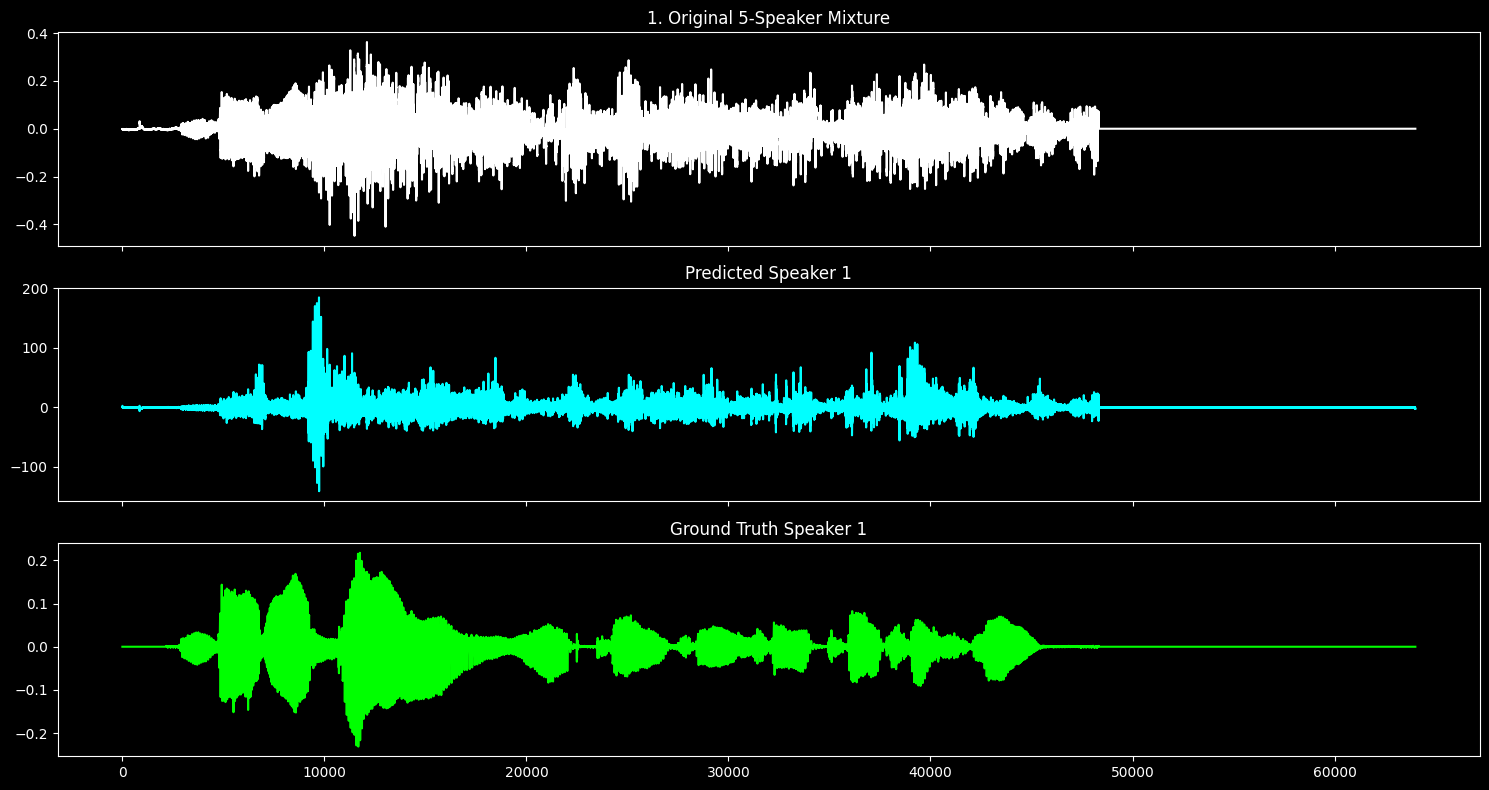

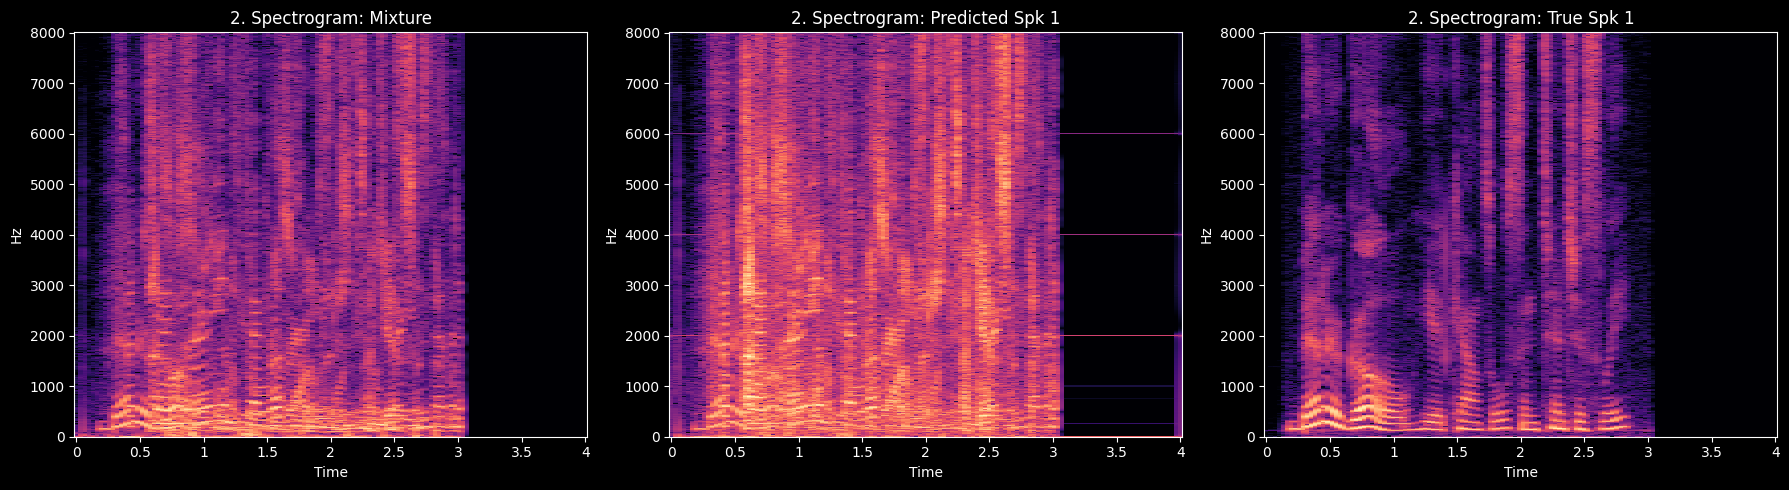

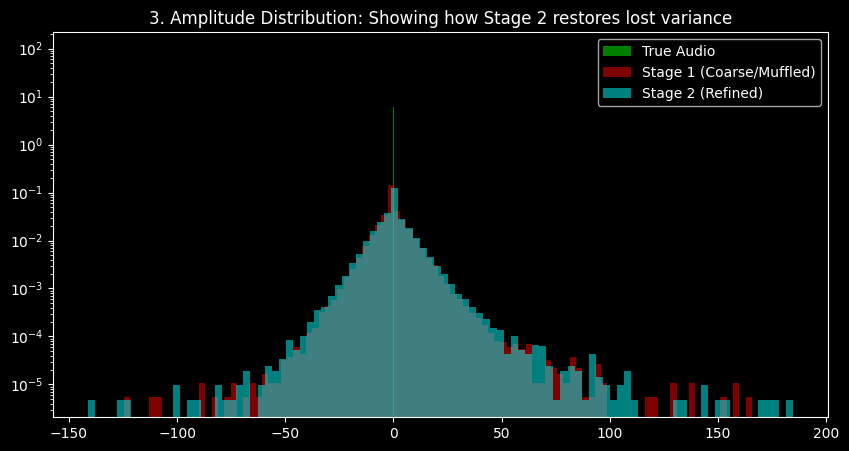

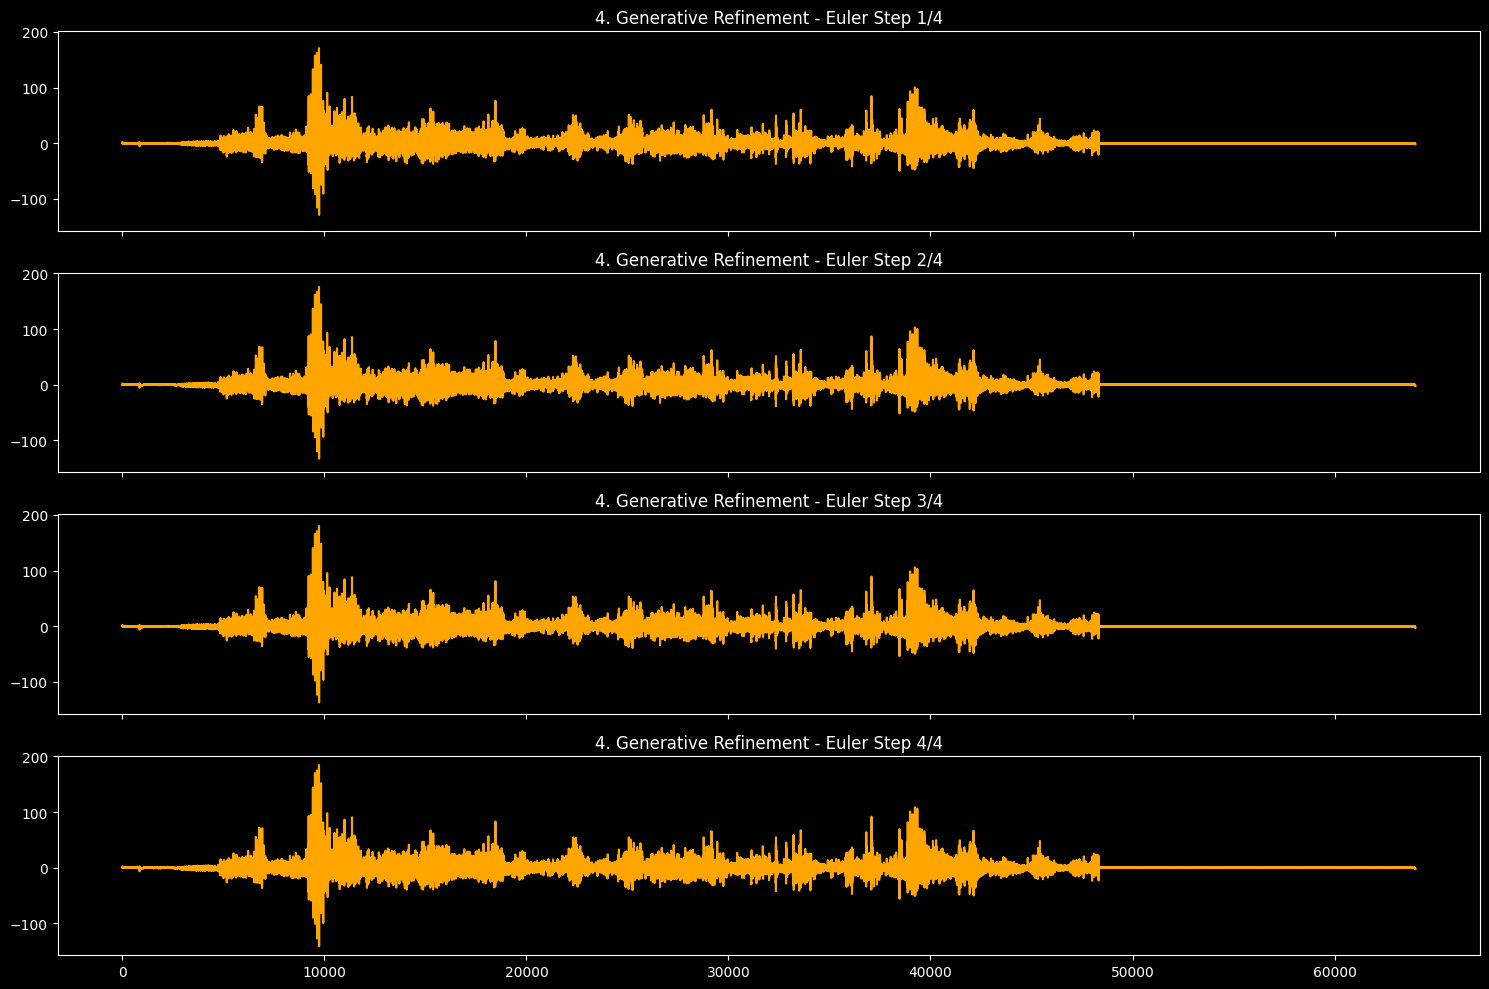

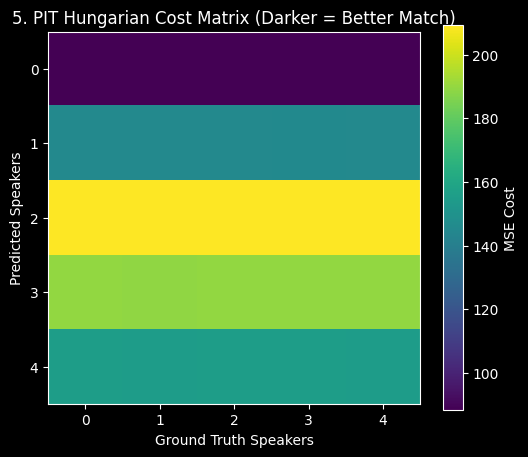

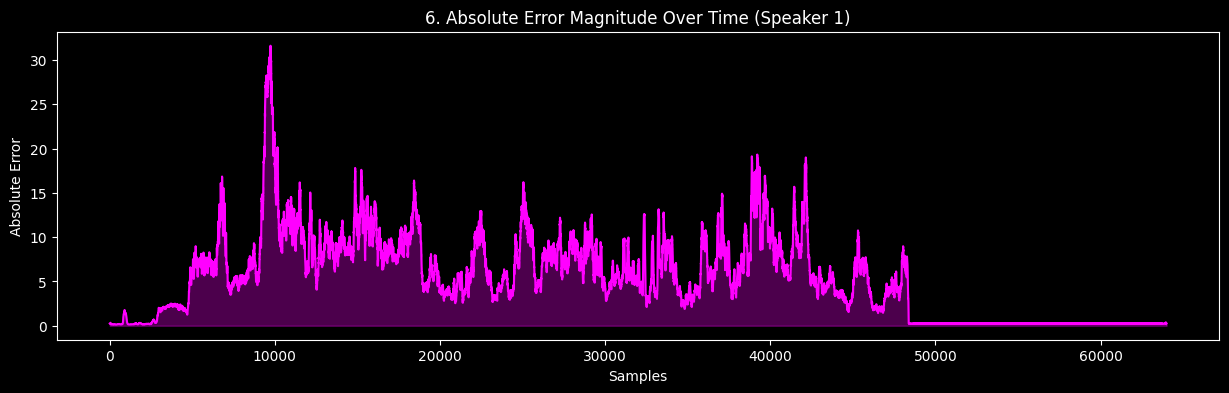

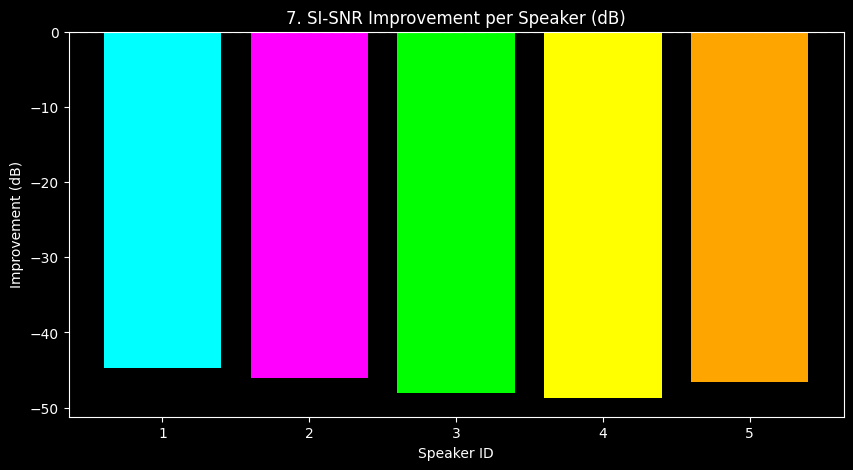

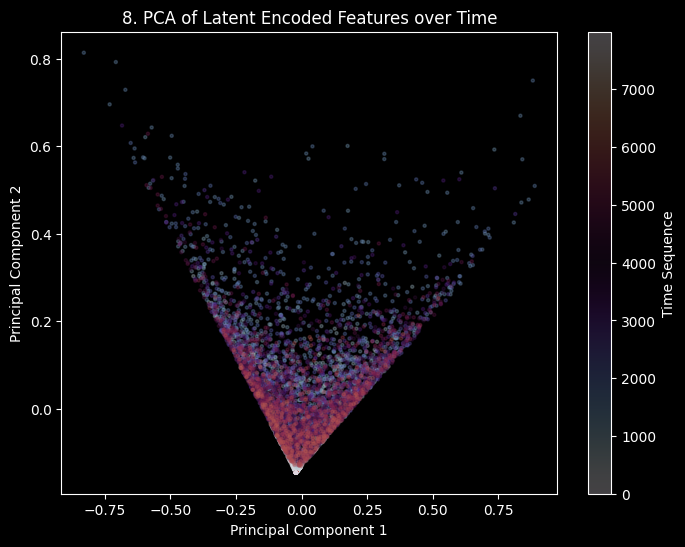

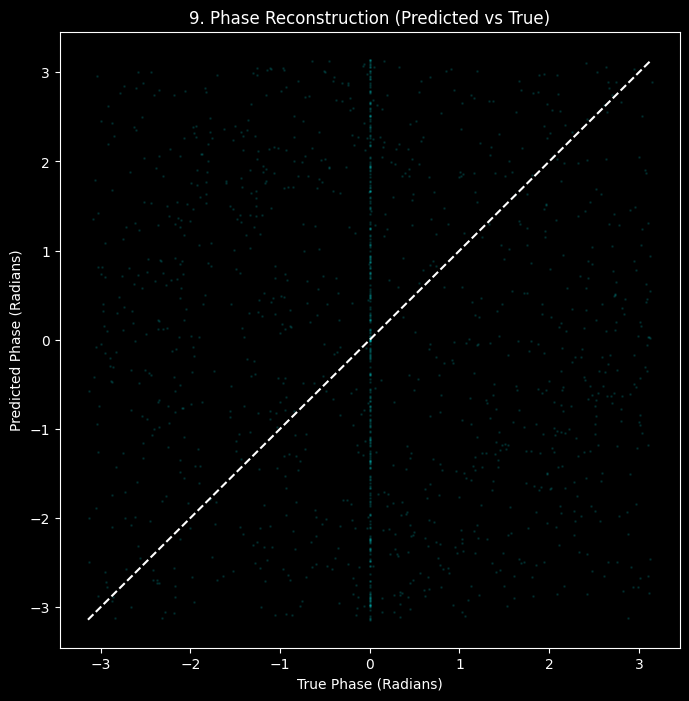

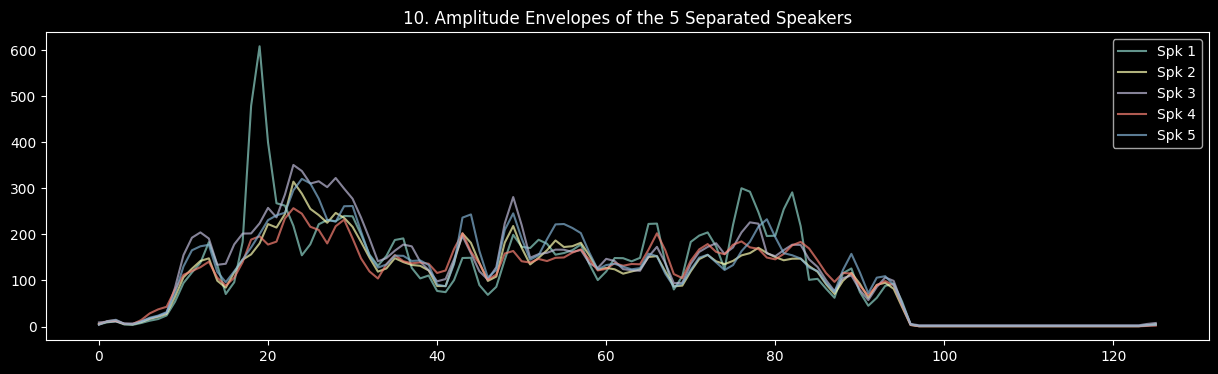

In [34]:
generate_visualizations(pipeline, test_loader, device)
